In [33]:
import os
import re
import json
from typing import TypedDict, Optional
from langgraph.graph import StateGraph, END
from groq import Groq
from dotenv import load_dotenv
import executor

# Load the .env file securely
load_dotenv()

# Initialize the Groq client
client = Groq()

In [34]:
class AgenticState(TypedDict):
    problem_description: str
    test_cases: list[dict]
    current_code: str
    execution_status: Optional[str]
    execution_logs: Optional[str]
    critic_feedback: Optional[str]
    iteration_count: int
    oracle_code: Optional[str]

def extract_cpp_code(response_text: str) -> str:
    pattern = r"`" * 3 + r"cpp\n(.*?)\n" + r"`" * 3
    match = re.search(pattern, response_text, re.DOTALL)
    code = match.group(1) if match else response_text
    return re.sub(r"<think>.*?</think>", "", code, flags=re.DOTALL).strip()

In [70]:
from rich.console import Console
from rich.panel import Panel
from rich.syntax import Syntax
from rich.markdown import Markdown

console = Console()

def oracle_node(state: AgenticState):
    console.print("\n[bold green]🔮 ORACLE NODE[/bold green]")

    prompt = (
        f"Problem: {state['problem_description']}\n\n"
        "Write a simple, correct Python function called `oracle(test_input: str) -> str` "
        "that takes a test input string (with real newlines) and returns the correct expected output string.\n"
        "CRITICAL: Do NOT attempt optimized logic (like sliding windows). You MUST use the dumbest, most rigorous brute-force approach possible (e.g., O(N^2) nested loops checking every single combination) to guarantee mathematical perfection.\n"
        "Return ONLY the Python function inside a python code block, nothing else."
    )

    chat_completion = client.chat.completions.create(
        messages=[{"role": "user", "content": prompt}],
        model="openai/gpt-oss-20b",
        temperature=0.1,
    )

    raw = chat_completion.choices[0].message.content
    match = re.search(r"```python\n(.*?)\n```", raw, re.DOTALL)
    oracle_code = match.group(1) if match else raw
    console.print("[green]Oracle function generated.[/green]")
    return {"oracle_code": oracle_code}


def test_generator_node(state: AgenticState):
    console.print("\n[bold yellow]🧪 TEST GENERATOR NODE[/bold yellow]")
    console.print("[dim]Brainstorming edge-case test constraints with Math Scratchpad...[/dim]")

    prompt = (
        f"Problem: {state['problem_description']}\n\n"
        "You are an adversarial QA engineer. Generate 3 tricky edge-case test cases.\n\n"
        "STEP 1 - UNDERSTAND THE I/O FORMAT:\n"
        "Re-read the problem description and write down exactly what each token/line of input represents.\n\n"
        "STEP 2 - GENERATE INPUTS:\n"
        "Create 3 inputs that stress edge cases. Format each 'input' exactly as it would be piped to stdin. "
        "CRITICAL RULE: At least ONE test case MUST contain a large input (at least 15 elements, e.g., a 4x4 matrix) to rigorously test memory boundaries. "
        "Use a literal escaped '\\n' string for newlines.\n\n"
        "STEP 3 - COMPUTE EXPECTED OUTPUT:\n"
        "Leave the expected output string blank or empty (e.g., \"\"). The Oracle will calculate this value.\n\n"
        "STEP 4 - SELF-CHECK:\n"
        "Ensure the structure is clean valid JSON.\n\n"
        "Output a JSON object with EXACTLY two keys:\n"
        "1. 'scratchpad': Your full Step 1-4 working as a single string.\n"
        "2. 'test_cases': An array of objects with exactly two string keys: 'input' and 'expected'."
    )

    # Note: response_format parameter removed to prevent API-level crashes
    chat_completion = client.chat.completions.create(
        messages=[{"role": "user", "content": prompt}],
        model="openai/gpt-oss-20b", 
        temperature=0.3,
    )

    raw_response = chat_completion.choices[0].message.content
    
    try:
        # Extract JSON using Regex in case the LLM wrapped it in markdown
        json_match = re.search(r"\{.*\}", raw_response, re.DOTALL)
        if json_match:
            raw_json = json.loads(json_match.group(0))
        else:
            raise ValueError("No JSON object found in response.")

        test_list = raw_json.get("test_cases", [])
        if not isinstance(test_list, list) or (len(test_list) > 0 and not isinstance(test_list[0], dict)):
            test_list = []

        if "scratchpad" in raw_json:
            scratchpad = raw_json["scratchpad"]
            if isinstance(scratchpad, list):
                scratchpad = "\n".join(scratchpad)
            console.print(Panel(str(scratchpad), title="[yellow]QA Agent Scratchpad (Internal Math)[/yellow]", border_style="yellow"))

    except Exception as e:
        console.print(f"[red]Test generator JSON parse failed: {e}[/red]")
        test_list = []

    # Override expected outputs using the oracle
    oracle_code = state.get("oracle_code") or ""
    if oracle_code:
        oracle_namespace = {}
        try:
            exec(oracle_code, oracle_namespace)
            oracle_fn = oracle_namespace.get("oracle")

            if oracle_fn:
                verified = []
                for test in test_list:
                    try:
                        real_input = test["input"].replace("\\n", "\n")
                        test["expected"] = oracle_fn(real_input).strip()
                        verified.append(test)
                    except Exception as e:
                        console.print(f"[red]Oracle failed on input '{test['input']}': {e}[/red]")
                test_list = verified
                console.print(f"[green]Oracle verified {len(test_list)} test cases.[/green]")
            else:
                console.print("[red]Oracle function not found in generated code — expected outputs unverified[/red]")

        except Exception as e:
            console.print(f"[red]Oracle exec failed: {e}[/red]")
    else:
        console.print("[yellow]No oracle available — using LLM-generated expected outputs (unreliable)[/yellow]")

    console.print(f"[green]Generated {len(test_list)} edge cases![/green]")
    return {"test_cases": test_list}


def coder_node(state: AgenticState):
    iteration = state['iteration_count'] + 1
    console.print(f"\n[bold blue]🤖 CODER NODE (Attempt {iteration})[/bold blue]")

    base_instruction = (
        "Write a highly optimized C++ solution including the main() function. "
        "Follow the I/O format described in the problem exactly. "
        "DO NOT print any conversational prompts. Print ONLY the final answer to std::cout."
    )

    if state.get("critic_feedback"):
        console.print("[yellow]Reading Critic's feedback and rewriting logic...[/yellow]")
        prompt = (
            f"{base_instruction}\n\n"
            f"Problem: {state['problem_description']}\n"
            f"Failed Code:\n{state['current_code']}\n\n"
            f"Error Feedback:\n{state['critic_feedback']}\n"
            "Provide ONLY the corrected C++ code inside a cpp block."
        )
    else:
        console.print("[cyan]Analyzing problem and writing initial C++ solution...[/cyan]")
        prompt = (
            f"{base_instruction}\n\n"
            f"Problem: {state['problem_description']}\n"
            "Provide ONLY the C++ code inside a cpp block."
        )

    chat_completion = client.chat.completions.create(
        messages=[{"role": "user", "content": prompt}],
        model="openai/gpt-oss-20b",
        temperature=0.3,
    )

    clean_code = extract_cpp_code(chat_completion.choices[0].message.content)
    syntax = Syntax(clean_code, "cpp", theme="monokai", line_numbers=True)
    console.print(Panel(syntax, title=f"Generated C++ (Attempt {iteration})", border_style="blue"))

    return {"current_code": clean_code, "iteration_count": iteration}


def executor_node(state: AgenticState):
    console.print("\n[bold magenta]⚙️ EXECUTOR NODE[/bold magenta]")

    test_cases = state.get("test_cases", [])

    if not test_cases:
        console.print("[bold red]No test cases available — aborting.[/bold red]")
        return {"execution_status": "test_failed", "execution_logs": "No test cases were generated."}

    console.print(f"[dim]Mounting Docker volume and running against {len(test_cases)} tests...[/dim]")

    for i, test in enumerate(test_cases):
        test_input = str(test.get("input", "")).replace("\\n", "\n").replace("\\t", "\t")
        expected_output = str(test.get("expected", "")).strip()

        console.print(f"  [cyan]Running Test Case {i+1}...[/cyan]")
        result = executor.run_cpp_code(state["current_code"], test_input)

        if result['status'] != 'success':
            console.print(Panel(result['logs'], title=f"[red]Test {i+1} Crashed ({result['status']})[/red]", border_style="red"))
            return {"execution_status": result["status"], "execution_logs": f"Test {i+1} Crashed:\n{result['logs']}"}

        actual_output = result['logs'].strip()
        if actual_output != expected_output:
            error_msg = f"Wrong Answer on Test {i+1}.\nInput provided:\n{test_input}\n\nExpected:\n{expected_output}\n\nGot:\n{actual_output}"
            console.print(Panel(error_msg, title=f"[red]Test {i+1} Failed (Logic Error)[/red]", border_style="red"))
            return {"execution_status": "test_failed", "execution_logs": error_msg}

        console.print(f"  [green]Test Case {i+1} Passed! ✅[/green]")

    console.print("[bold green]All test cases passed![/bold green]")
    return {"execution_status": "success", "execution_logs": "All tests passed."}


def critic_node(state: AgenticState):
    console.print("\n[bold red]🧐 CRITIC NODE[/bold red]")
    console.print("[dim]Analyzing Sandbox logs and formulating fix...[/dim]")

    prompt = (
        f"The C++ code failed the sandbox tests.\nCode:\n{state['current_code']}\n\n"
        f"Test Suite:\n{json.dumps(state['test_cases'], indent=2)}\n\n"
        f"Failure on:\nStatus: {state['execution_status']}\nLogs: {state['execution_logs']}\n\n"
        "Explain exactly why this failed and what needs to be changed."
    )

    chat_completion = client.chat.completions.create(
        messages=[{"role": "user", "content": prompt}],
        model="openai/gpt-oss-20b",
        temperature=0.3,
    )

    feedback = chat_completion.choices[0].message.content
    console.print(Panel(Markdown(feedback), title="Critic Analysis", border_style="red"))
    return {"critic_feedback": feedback}

In [71]:
def route_execution(state: AgenticState):
    if state["execution_status"] == "success":
        console.print("\n[bold green]🏁 PIPELINE COMPLETE. C++ Code is production-ready.[/bold green]")
        return "end"
    elif state["iteration_count"] >= 3:
        console.print("\n[bold red]❌ Max iterations reached. Killing graph.[/bold red]")
        return "end"
    else:
        console.print("\n[bold yellow]🔄 Routing to Critic for self-correction...[/bold yellow]")
        return "critic"

workflow = StateGraph(AgenticState)

workflow.add_node("oracle", oracle_node)
workflow.add_node("test_generator", test_generator_node)
workflow.add_node("coder", coder_node)
workflow.add_node("executor", executor_node)
workflow.add_node("critic", critic_node)

workflow.set_entry_point("oracle")
workflow.add_edge("oracle", "test_generator")
workflow.add_edge("test_generator", "coder")
workflow.add_edge("coder", "executor")
workflow.add_conditional_edges("executor", route_execution, {"end": END, "critic": "critic"})
workflow.add_edge("critic", "coder")

app = workflow.compile()

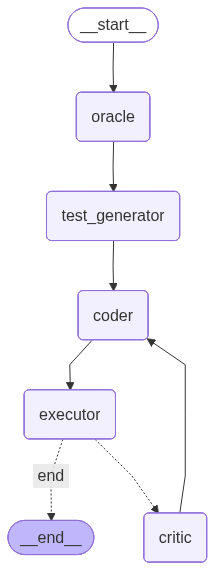

In [72]:
from IPython.display import Image

Image(app.get_graph().draw_mermaid_png())

In [76]:
initial_state = {
    "problem_description": (
        "Write a C++ program to implement an LRU (Least Recently Used) Cache. "
        "Read two integers: C (capacity) and Q (number of queries). "
        "Then read Q lines. If the line starts with '1', read two more integers K and V, and PUT(K, V) into the cache. "
        "If the line starts with '2', read one more integer K, and GET(K). "
        "For every GET query, output the value (or -1 if not found) on a new line. "
        "CRITICAL: Both GET and PUT must strictly run in O(1) time complexity. Use a hash map and a doubly linked list. "
        "Read all inputs from std::cin until EOF. Do not print any conversational UI text."
    ),
    "execution_status": None,
    "execution_logs": None,
    "critic_feedback": None,
    "iteration_count": 0,
    "test_cases": [],
    "current_code": "",
    "oracle_code": None
}

console.print("[bold magenta]🚀 Firing up the 4-Node Agentic Pipeline...[/bold magenta]")
final_state = app.invoke(initial_state)

🚀 Firing up the 4-Node Agentic Pipeline...

🔮 ORACLE NODE

Oracle function generated.

🧪 TEST GENERATOR NODE

Brainstorming edge-case test constraints with Math Scratchpad...

...

Analyzing problem and writing initial C++ solution...

╭─────────────────────────────────────────── Generated C++ (Attempt 3) ───────────────────────────────────────────╮
│    1 #include <bits/stdc++.h>                                                                                   │
│    2 using namespace std;                                                                                       │
│    3                                                                                                            │
│    4 struct Node {                                                                                              │
│    5     long long key, val;                                                                                    │
│    6     Node* prev;                                                                                            │
│    7     Node* next;                                                                                            │
│    8     Node(long long k = 0, long long v = 0) : key(k), val(v), prev(nullptr), next(nullptr) {}               │
│    9 };                                                                                                         │
│   10                                                                                                            │
│   11 class LRUCache {                                                                                           │
│   12     int capacity;                                                                                          │
│   13     unordered_map<long long, Node*> mp;                                                                    │
│   14     Node* head;                                                                                            │
│   15     Node* tail;                                                                                            │
│   16     int size;                                                                                              │
│   17                                                                                                            │
│   18     void remove(Node* node) {                                                                              │
│   19         node->prev->next = node->next;                                                                     │
│   20         node->next->prev = node->prev;                                                                     │
│   21     }                                                                                                      │
│   22                                                                                                            │
│   23     void insertFront(Node* node) {                                                                         │
│   24         node->next = head->next;                                                                           │
│   25         node->prev = head;                                                                                 │
│   26         head->next->prev = node;                                                                           │
│   27         head->next = node;                                                                                 │
│   28     }                                                                                                      │
│   29                                                                                                            │
│   30 public:                                                                                                    │
│   31     [38

⚙️ EXECUTOR NODE

No test cases available — aborting.

❌ Max iterations reached. Killing graph.